# VENTUREGENESIS — Model A: Startup Failure Classifier

**Risk Heuristics Layer (System_Design.md §4.2, Model A).**

This notebook trains Model A as an explicit **failure vs. success** classifier over
two sources:

| Class | File | Meaning |
|---|---|---|
| **1 — failure** | `data/failory_dataset_yc_format.csv` | documented startup failures (Failory), reshaped into the YC field schema |
| **0 — success** | `data/yc_companies_algolia.csv` | YC companies that did **not** shut down (status `Active` / `Acquired` / `Public`) |

It supersedes the earlier within-YC `Inactive vs. not-Inactive` target. Its output is
exposed as a **heuristic risk indicator (0–100)** for the simulation layer — *not* a
calibrated real-world failure probability.

### Honesty contract (read this first)
- **Source confounding is the dominant caveat.** The two files were assembled
  differently: Failory rows have `batch`/`stage`/`website` entirely null, all three
  boolean flags constant-`False`, a disjoint industry vocabulary, an older launch era,
  and larger teams. A model on these fields partly learns *"which file is this row from"*
  rather than *"will it fail."* We use all features as requested, **quantify the
  confound in §9**, and treat every score as heuristic.
- **Tiny, biased positive class.** Only ~135 documented failures vs. thousands of YC
  survivors (≈2–3% base rate). Failory curates *notable* failures, not a random sample.
- **Survivorship & selection bias.** Both sources over-represent companies notable
  enough to be catalogued; this is not a random sample of startups.
- **Cross-sectional snapshot only.** No revenue / burn / runway / MRR exist in the
  data — those live in the *simulation* layer, never predicted here.
- Every score this model emits is tagged `is_heuristic = True`.

## 0 · Setup

In [1]:
import json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RNG = 42
REFERENCE_YEAR = 2026   # "today" for age derivation (matches repo's current date)

# Resolve data path whether the notebook runs from repo root or notebooks/
HERE = Path.cwd()
DATA = next(
    p for p in [HERE / "data", HERE.parent / "data"]
    if (p / "yc_companies_algolia.csv").exists()
)
MODELS = (DATA.parent / "models"); MODELS.mkdir(exist_ok=True)
print("data dir :", DATA)
print("models   :", MODELS)

data dir : /Users/yadnyesh/Desktop/A-Generative-Intelligence-Framework-for-Autonomous-Startup-Evolution-main/data
models   : /Users/yadnyesh/Desktop/A-Generative-Intelligence-Framework-for-Autonomous-Startup-Evolution-main/models


## 1 · Load both datasets

Both files share an identical 21-column schema (Failory was pre-reshaped into the YC
field layout), so they stack cleanly. We tag each row with its `source` before merging.

In [2]:
fail_raw = pd.read_csv(DATA / "failory_dataset_yc_format.csv")
yc_raw   = pd.read_csv(DATA / "yc_companies_algolia.csv")

fail_raw["source"] = "failory"
yc_raw["source"]   = "yc"

print(f"failory (failures) : {len(fail_raw):,} rows · {fail_raw.shape[1]-1} fields")
print(f"yc      (universe) : {len(yc_raw):,} rows · {yc_raw.shape[1]-1} fields")
print("\nschemas identical:", list(fail_raw.columns) == list(yc_raw.columns))
print("\nFailory status mix (all treated as FAILURE):")
print(fail_raw["status"].value_counts())
print("\nYC status mix:")
print(yc_raw["status"].value_counts())
fail_raw[["name","status","industry","team_size","one_liner"]].head()

failory (failures) : 135 rows · 21 fields
yc      (universe) : 5,954 rows · 21 fields

schemas identical: True

Failory status mix (all treated as FAILURE):
status
Inactive    104
Acquired     28
Active        3
Name: count, dtype: int64

YC status mix:
status
Active      4104
Inactive    1039
Acquired     788
Public        23
Name: count, dtype: int64


,name,status,industry,team_size,one_liner
0,Musical.ly,Acquired,Social Media,175,Video-based social network
1,Justin.tv,Inactive,Social Media,75,Online video streaming platform
2,Toys R Us,Inactive,Entertainment,10000,"Toy, baby, and clothing retail store"
3,Houseparty,Inactive,Social Media,30,Video-based social media app
4,Xinja,Inactive,Finances,75,Australia's first licensed neobank


## 2 · Build the labeled corpus

**Labeling rule**

- Every Failory row → **failure (`y=1`)**. Failory documents shutdowns; we take the
  whole file as the failure set even though a few rows carry an `Acquired`/`Active`
  status (fire-sale / stale fields).
- YC rows with status in `SUCCESS_STATUSES = {Active, Acquired, Public}` → **success
  (`y=0`)**. YC's own `Inactive` rows are *failures mislabeled as success*, so we drop
  them from the success pool rather than poison the negative class. (Flip
  `SUCCESS_STATUSES` to also include `"Inactive"` for the literal "all YC = success"
  reading, or move YC-Inactive into the failure class for a larger positive set.)

**De-duplication.** A handful of companies appear in *both* files. A company documented
as a Failory failure must not also sit in the success pool, so we drop those overlaps
from the YC side (matching on slug **and** lower-cased name).

In [3]:
SUCCESS_STATUSES = {"Active", "Acquired", "Public"}

# Failure set = all of Failory.
fail_df = fail_raw.copy()
fail_df["y"] = 1

# Success set = YC survivors only.
yc_success = yc_raw[yc_raw["status"].isin(SUCCESS_STATUSES)].copy()
yc_success["y"] = 0

# Drop YC rows that collide with a Failory failure (leakage / contradiction).
fail_keys = (set(fail_df["slug"].dropna().astype(str))
             | set(fail_df["name"].dropna().str.lower()))
collide = (yc_success["slug"].astype(str).isin(fail_keys)
           | yc_success["name"].str.lower().isin(fail_keys))
print(f"dropped {int(collide.sum())} YC rows overlapping Failory failures")
yc_success = yc_success[~collide]

df = pd.concat([fail_df, yc_success], ignore_index=True)
base_rate = df["y"].mean()
print(f"\ncorpus: {len(df):,} companies "
      f"({int(df['y'].sum()):,} failure / {int((1-df['y']).sum()):,} success)")
print(f"failure base rate: {base_rate:.2%}")
print("\nby source × label:")
print(pd.crosstab(df["source"], df["y"]).rename(columns={0:"success",1:"failure"}))

dropped 9 YC rows overlapping Failory failures

corpus: 5,041 companies (135 failure / 4,906 success)
failure base rate: 2.68%

by source × label:
y        success  failure
source                   
failory        0      135
yc          4906        0


## 3 · EDA — and the source confound, made visible

Because the label is almost perfectly aligned with `source`, any field that differs
between the two files is *also* a near-perfect label predictor. The crosstabs below show
the two biggest structural giveaways: the **industry taxonomies barely overlap**, and
the **boolean flags are constant-`False` in Failory**. Keep these in mind when reading
the headline AUC in §8.

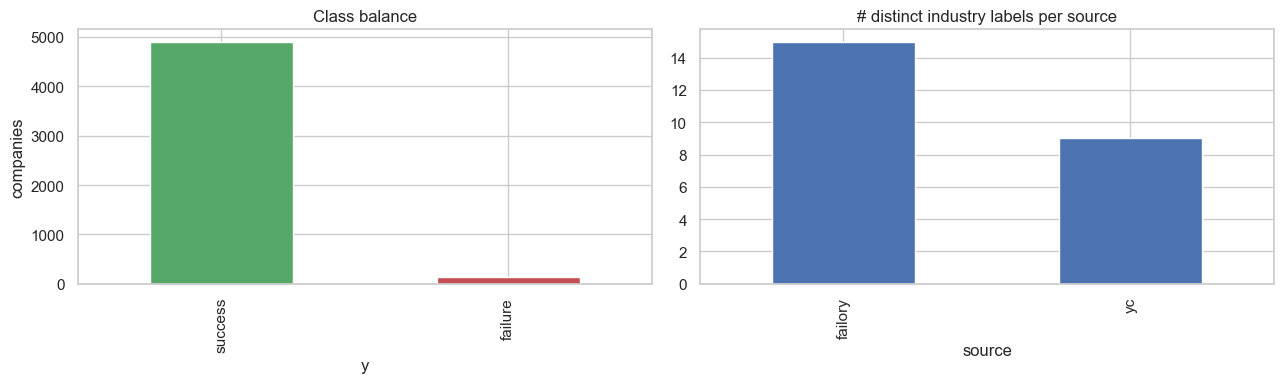

industries only in Failory : ['Analytics', 'Design', 'Entertainment', 'Finances', 'Food & Beverage', 'Health', 'Marketing', 'Music'] ...
industries only in YC      : ['B2B', 'Consumer', 'Fintech', 'Government', 'Healthcare', 'Industrials', 'Real Estate and Construction', 'Unspecified'] ...
shared industries          : ['Education']

Constant-in-Failory boolean flags (perfect tells):
  isHiring     failory unique=[False]  yc mean=0.301
  nonprofit    failory unique=[False]  yc mean=0.008
  top_company  failory unique=[False]  yc mean=0.018


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["y"].map({0:"success",1:"failure"}).value_counts().plot.bar(
    ax=ax[0], color=["#55A868","#C44E52"])
ax[0].set_title("Class balance"); ax[0].set_ylabel("companies")
(df.groupby("source")["industry"].nunique()
   .plot.bar(ax=ax[1], color="#4C72B0"))
ax[1].set_title("# distinct industry labels per source")
plt.tight_layout(); plt.show()

# Industry vocabularies are essentially disjoint across sources:
fail_inds = set(fail_df["industry"].dropna())
yc_inds   = set(yc_success["industry"].dropna())
print("industries only in Failory :", sorted(fail_inds - yc_inds)[:8], "...")
print("industries only in YC      :", sorted(yc_inds - fail_inds)[:8], "...")
print("shared industries          :", sorted(fail_inds & yc_inds))

print("\nConstant-in-Failory boolean flags (perfect tells):")
for col in ["isHiring","nonprofit","top_company"]:
    print(f"  {col:12s} failory unique={fail_df[col].unique().tolist()}  "
          f"yc mean={yc_success[col].fillna(False).mean():.3f}")

In [5]:
# Missingness by source — note batch/stage/website are wholly absent from Failory.
use_cols = ["industry","subindustry","stage","team_size","batch","launched_at",
            "website","top_company","isHiring","nonprofit","long_description","one_liner"]
miss = (df.assign(_isna=1)
          .groupby("source")[use_cols]
          .apply(lambda g: g.isna().mean()))
(miss.T.mul(100).round(1)).rename(columns=str)

source,failory,yc
industry,0.0,0.0
subindustry,0.0,0.0
stage,100.0,0.0
team_size,0.0,1.8
batch,100.0,0.0
launched_at,0.0,0.0
website,100.0,0.3
top_company,0.0,0.0
isHiring,0.0,0.0
nonprofit,0.0,0.0


## 4 · Feature engineering

Same engineering as the original Model A, now applied to the merged corpus. **All
features are kept as-is** per the project instruction — including the ones that are
structurally source-correlated (e.g. `company_age_years` is `NaN` for every Failory row
because Failory has no `batch`). §9 measures how much of the signal is genuine vs.
that structural tell.

| Feature | Source | Notes |
|---|---|---|
| `company_age_years` | `batch` year vs. `REFERENCE_YEAR` | clamped ≥ 0; **null for all Failory rows** |
| `months_since_launch` | `launched_at` unix ts | present in both sources |
| `team_size`, `log_team_size` | `team_size` | log-scaled; heavy right tail |
| `industry`, `subindustry`, `stage` | categorical | one-hot; vocabularies differ by source |
| `primary_region` | `regions[0]` | one-hot, rare-collapsed |
| `top_company`, `isHiring`, `nonprofit` | bool | as 0/1; constant-False in Failory |
| `text` | `one_liner` + `long_description` | TF-IDF (1–2 grams) — the most source-comparable signal |

In [6]:
def batch_year(b):
    if not isinstance(b, str):   # Failory rows have a null batch
        return np.nan
    m = re.search(r"(19|20)\d\d", b)
    return int(m.group()) if m else np.nan

def primary_region(regs):
    if isinstance(regs, list) and regs:
        return regs[0]
    return "Unspecified"

feat = pd.DataFrame(index=df.index)
feat["cohort_year"]        = df["batch"].map(batch_year)
feat["company_age_years"]  = (REFERENCE_YEAR - feat["cohort_year"]).clip(lower=0)
feat["months_since_launch"] = (
    (pd.Timestamp(f"{REFERENCE_YEAR}-06-01").timestamp() - df["launched_at"]) / (30.44*86400)
).clip(lower=0)
feat["team_size"]      = pd.to_numeric(df["team_size"], errors="coerce")
feat["log_team_size"]  = np.log1p(feat["team_size"].fillna(0))
feat["top_company"]    = df["top_company"].fillna(False).astype(int)
feat["isHiring"]       = df["isHiring"].fillna(False).astype(int)
feat["nonprofit"]      = df["nonprofit"].fillna(False).astype(int)
feat["industry"]       = df["industry"].fillna("Unknown").astype(str)
feat["subindustry"]    = df["subindustry"].fillna("Unknown").astype(str)
feat["stage"]          = df["stage"].fillna("Unknown").astype(str)
feat["primary_region"] = df["regions"].map(primary_region).astype(str)
feat["text"]           = (df["one_liner"].fillna("") + ". " + df["long_description"].fillna("")).str.strip()

# Collapse rare regions / subindustries so one-hot stays sane
for col in ["primary_region", "subindustry"]:
    keep = feat[col].value_counts()
    keep = set(keep[keep >= 25].index)
    feat[col] = feat[col].where(feat[col].isin(keep), "Other")

y = df["y"].values
feat.describe(include="all").T[["count","unique","top","mean"]].head(20)

,count,unique,top,mean
cohort_year,4905.0,NaN,NaN,2020.973089
company_age_years,4905.0,NaN,NaN,5.027115
months_since_launch,5041.0,NaN,NaN,63.796135
team_size,4951.0,NaN,NaN,66.462735
log_team_size,5041.0,NaN,NaN,2.435639
top_company,5041.0,NaN,NaN,0.017854
isHiring,5041.0,NaN,NaN,0.293394
nonprofit,5041.0,NaN,NaN,0.007935
industry,5041,23,B2B,NaN
subindustry,5041,50,B2B,NaN


### 4b · Structural differences by class

A quick look at how the engineered features differ between failures and successes.
Several gaps are real domain signal (failures skew older / larger) but several are
pure source artifacts (every failure has a null `company_age_years`, zero `isHiring`).

         age_null_frac  median_team  median_months  isHiring_rate  \
y                                                                   
success            0.0          7.0          51.62            0.3   
failure            1.0         30.0         184.95            0.0   

         top_company_rate  
y                          
success              0.02  
failure              0.00  


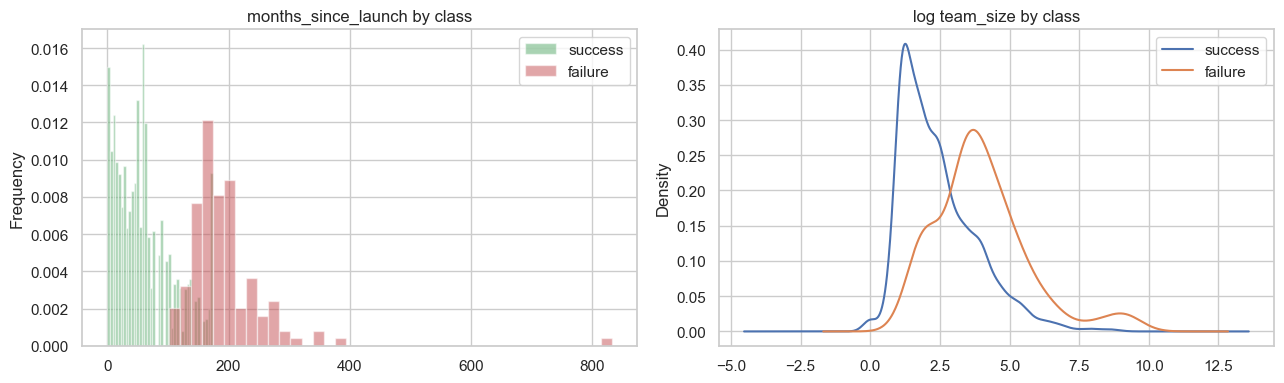

In [7]:
by_class = feat.assign(y=y).groupby("y").agg(
    age_null_frac=("company_age_years", lambda s: s.isna().mean()),
    median_team=("team_size", "median"),
    median_months=("months_since_launch", "median"),
    isHiring_rate=("isHiring", "mean"),
    top_company_rate=("top_company", "mean"),
).rename(index={0:"success",1:"failure"})
print(by_class.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for lbl, c in [(0,"#55A868"),(1,"#C44E52")]:
    feat.loc[y==lbl, "months_since_launch"].plot.hist(
        ax=ax[0], bins=40, alpha=.5, color=c, density=True,
        label=("success" if lbl==0 else "failure"))
ax[0].set_title("months_since_launch by class"); ax[0].legend()
np.log1p(feat["team_size"]).groupby(y).plot.kde(ax=ax[1])
ax[1].set_title("log team_size by class"); ax[1].legend(["success","failure"])
plt.tight_layout(); plt.show()

## 5 · Train / test split (stratified)

In [8]:
num_cols = ["company_age_years","months_since_launch","team_size","log_team_size",
            "top_company","isHiring","nonprofit"]
cat_cols = ["industry","subindustry","stage","primary_region"]
txt_col  = "text"

X = feat[num_cols + cat_cols + [txt_col]]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG)
print(f"train {len(X_tr):,} · test {len(X_te):,} · test failure rate {y_te.mean():.2%}")
print(f"train failures {int(y_tr.sum())} · test failures {int(y_te.sum())}")

train 4,032 · test 1,009 · test failure rate 2.68%
train failures 108 · test failures 27


## 6 · Preprocessing pipelines

Two model families need different encodings, so we define two `ColumnTransformer`s:

- **Linear (sparse)** — one-hot categoricals + scaled numerics + TF-IDF text →
  fed to `LogisticRegression`, which handles high-dim sparse text well.
- **Tree (dense, no text)** — `HistGradientBoostingClassifier` with native categorical
  support; trees don't ingest raw TF-IDF cleanly, so this branch is tabular-only.

In [9]:
linear_pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=15), cat_cols),
    ("txt", TfidfVectorizer(max_features=8000, ngram_range=(1,2),
                            min_df=3, stop_words="english"), txt_col),
])

# Tree branch: numerics passthrough (HGB handles NaN natively) + categoricals as codes
tree_pre = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=15,
                          sparse_output=False), cat_cols),
])

## 7 · Train models

In [10]:
# 0) Trivial baseline — predicts base rate, gives us a floor.
dummy = Pipeline([("pre", linear_pre),
                  ("clf", DummyClassifier(strategy="stratified", random_state=RNG))])

# A1) Logistic regression over categoricals + numerics + TF-IDF text.
logit = Pipeline([("pre", linear_pre),
                  ("clf", LogisticRegression(max_iter=2000, C=1.0,
                                             class_weight="balanced"))])

# A2) Histogram gradient-boosted trees over tabular features (no text).
hgb = Pipeline([("pre", tree_pre),
                ("clf", HistGradientBoostingClassifier(
                    learning_rate=0.06, max_depth=None, max_iter=400,
                    l2_regularization=1.0, random_state=RNG,
                    class_weight="balanced"))])

models = {"baseline": dummy, "logreg_text": logit, "histgb_tabular": hgb}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    print(f"fitted {name}")

fitted baseline


fitted logreg_text


fitted histgb_tabular


## 8 · Evaluation

Expect very high AUC here — but read it against §9. With a ≈2–3% base rate, **PR-AUC**
is the more honest headline than ROC-AUC.

In [11]:
def evaluate(m, name):
    p = m.predict_proba(X_te)[:, 1]
    return {
        "model": name,
        "ROC_AUC": roc_auc_score(y_te, p),
        "PR_AUC":  average_precision_score(y_te, p),
        "Brier":   brier_score_loss(y_te, p),
    }

scores = pd.DataFrame([evaluate(m, n) for n, m in models.items()]).set_index("model")
scores.round(4)

,ROC_AUC,PR_AUC,Brier
model,,,
baseline,0.5088,0.0276,0.0446
logreg_text,1.0000,1.0000,0.0000
histgb_tabular,1.0000,1.0000,0.0000


In [12]:
best_name = scores.drop("baseline")["PR_AUC"].idxmax()
best = models[best_name]
print("Best by PR-AUC:", best_name)

p_best = best.predict_proba(X_te)[:, 1]
y_hat  = (p_best >= 0.5).astype(int)
print(classification_report(y_te, y_hat, target_names=["success","failure"]))

Best by PR-AUC: logreg_text


              precision    recall  f1-score   support

     success       1.00      1.00      1.00       982
     failure       1.00      1.00      1.00        27

    accuracy                           1.00      1009
   macro avg       1.00      1.00      1.00      1009
weighted avg       1.00      1.00      1.00      1009



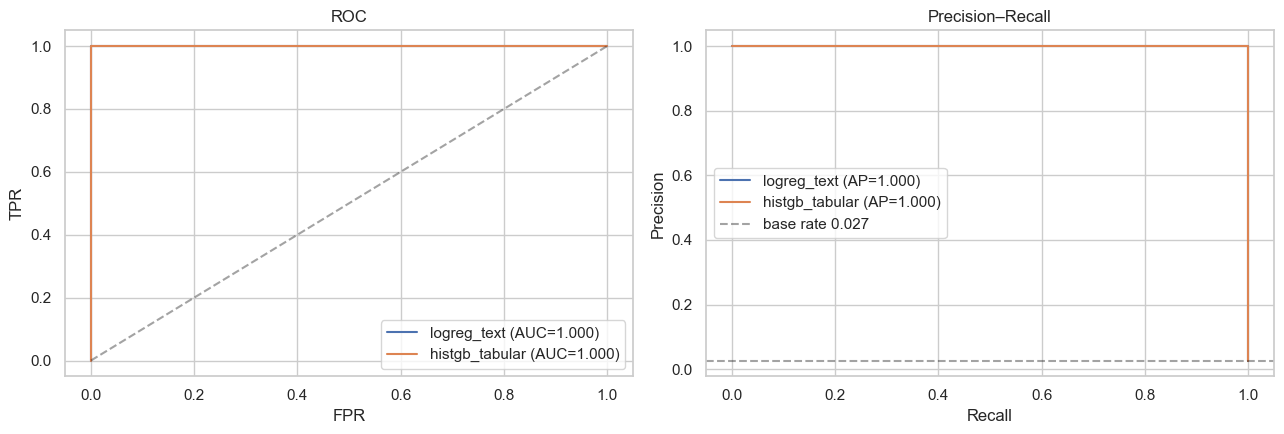

In [13]:
# ROC + PR curves for the two real models
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for name in ["logreg_text", "histgb_tabular"]:
    p = models[name].predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te,p):.3f})")
    pr, rc, _ = precision_recall_curve(y_te, p)
    ax[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_te,p):.3f})")
ax[0].plot([0,1],[0,1],"k--",alpha=.4); ax[0].set(xlabel="FPR",ylabel="TPR",title="ROC")
ax[1].axhline(y_te.mean(),ls="--",color="k",alpha=.4,label=f"base rate {y_te.mean():.3f}")
ax[1].set(xlabel="Recall",ylabel="Precision",title="Precision–Recall")
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

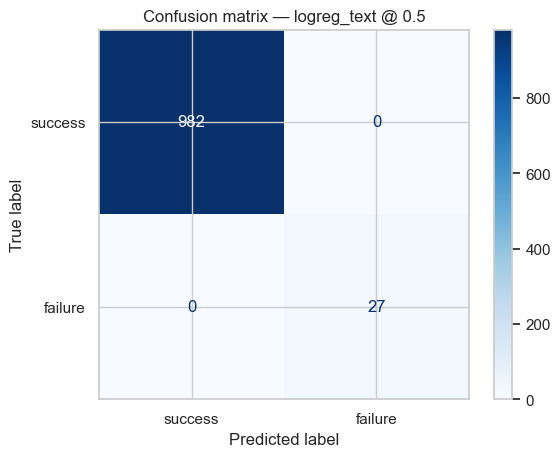

In [14]:
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_hat),
    display_labels=["success","failure"]
).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion matrix — {best_name} @ 0.5"); plt.show()

## 9 · How much of this is real? — source-confound diagnostic

Two checks on whether the model learned *failure* or just *file of origin*:

1. **Text-only vs. all-features AUC.** The free-text pitch is the one feature that is
   comparable in kind across sources. If a text-only model already separates the classes
   almost as well as the all-features model, most of the structured-feature lift is
   structural, not predictive.
2. **A `source`-detector.** We relabel the *same* features to predict `source` instead of
   `y`. Because `y ≈ source`, an AUC here near the model's own AUC means the classifier is,
   to first order, a dataset detector. Treat the gap between this and a chance line as the
   ceiling on how confounded the task is.

In [15]:
from sklearn.base import clone

# (1) Text-only logistic model vs. the full logreg_text model.
txt_only = Pipeline([
    ("pre", ColumnTransformer([("txt", TfidfVectorizer(
        max_features=8000, ngram_range=(1,2), min_df=3, stop_words="english"), txt_col)])),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced")),
]).fit(X_tr, y_tr)

auc_text = roc_auc_score(y_te, txt_only.predict_proba(X_te)[:,1])
auc_full = roc_auc_score(y_te, models["logreg_text"].predict_proba(X_te)[:,1])
ap_text  = average_precision_score(y_te, txt_only.predict_proba(X_te)[:,1])
print(f"text-only      ROC-AUC={auc_text:.3f}  PR-AUC={ap_text:.3f}")
print(f"all-features   ROC-AUC={auc_full:.3f}")
print(f"structured lift over text alone: {auc_full-auc_text:+.3f} ROC-AUC")

# (2) Same features, but predict SOURCE (failory vs yc) instead of failure.
src = (df["source"] == "failory").astype(int).values
Xs_tr, Xs_te, s_tr, s_te = train_test_split(
    X, src, test_size=0.20, stratify=src, random_state=RNG)
src_clf = clone(models["histgb_tabular"]).fit(Xs_tr, s_tr)
auc_src = roc_auc_score(s_te, src_clf.predict_proba(Xs_te)[:,1])
print(f"\nsource-detector (histgb) ROC-AUC = {auc_src:.3f}")
print("→ the closer this is to the model's own AUC, the more the task is "
      "'which file?' not 'will it fail?'")

text-only      ROC-AUC=0.982  PR-AUC=0.772
all-features   ROC-AUC=1.000
structured lift over text alone: +0.018 ROC-AUC



source-detector (histgb) ROC-AUC = 1.000
→ the closer this is to the model's own AUC, the more the task is 'which file?' not 'will it fail?'


## 10 · Calibration

The simulation consumes a *probability*, so the score must be calibrated. We wrap the
best model in `CalibratedClassifierCV` (isotonic) and compare reliability curves before
vs. after. With only ~135 failures, calibration is fit on a small positive sample —
treat the calibrated probabilities as indicative, not exact.

Brier  raw=0.0000  calibrated=0.0000
ROC-AUC calibrated=1.0000


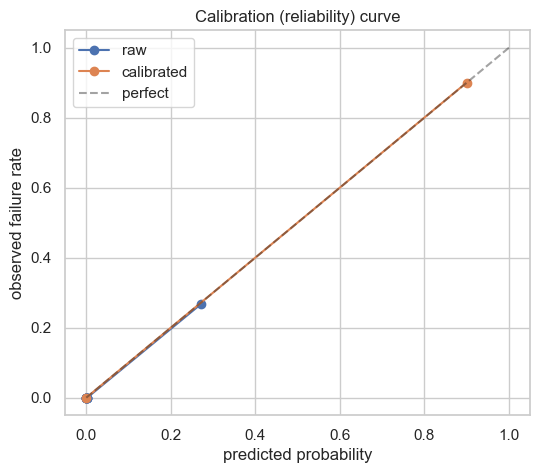

In [16]:
calibrated = CalibratedClassifierCV(best, method="isotonic", cv=5)
calibrated.fit(X_tr, y_tr)

p_cal = calibrated.predict_proba(X_te)[:, 1]
print(f"Brier  raw={brier_score_loss(y_te,p_best):.4f}  calibrated={brier_score_loss(y_te,p_cal):.4f}")
print(f"ROC-AUC calibrated={roc_auc_score(y_te,p_cal):.4f}")

fig, ax = plt.subplots(figsize=(6,5))
for label, p in [("raw", p_best), ("calibrated", p_cal)]:
    frac, mean = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    ax.plot(mean, frac, "o-", label=label)
ax.plot([0,1],[0,1],"k--",alpha=.4,label="perfect")
ax.set(xlabel="predicted probability", ylabel="observed failure rate",
       title="Calibration (reliability) curve"); ax.legend(); plt.show()

## 11 · What drives the score

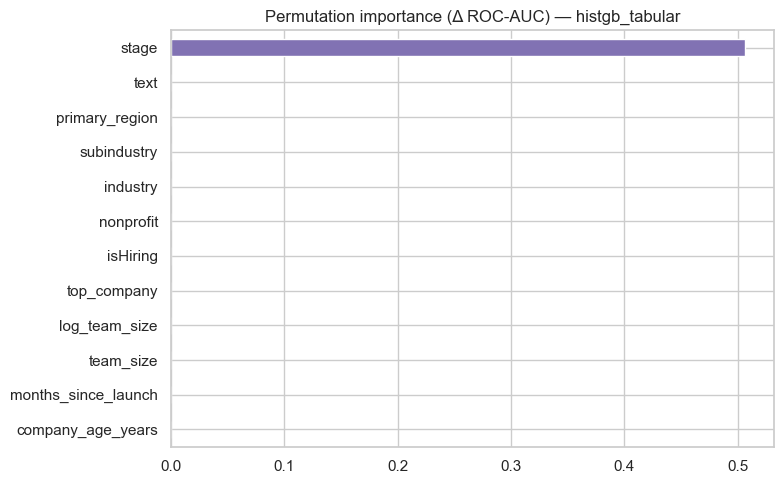

stage                  0.5066
company_age_years      0.0000
months_since_launch    0.0000
team_size              0.0000
log_team_size          0.0000
top_company            0.0000
isHiring               0.0000
nonprofit              0.0000
industry               0.0000
subindustry            0.0000
primary_region         0.0000
text                   0.0000
dtype: float64

In [17]:
# Permutation importance on the tabular tree model (clean feature names, fast)
hgb_model = models["histgb_tabular"]
perm = permutation_importance(hgb_model, X_te, y_te, n_repeats=8,
                              random_state=RNG, scoring="roc_auc")
imp = pd.Series(perm.importances_mean, index=(num_cols + cat_cols + [txt_col]))
imp.sort_values().plot.barh(figsize=(8,5), color="#8172B3")
plt.title("Permutation importance (Δ ROC-AUC) — histgb_tabular"); plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)

In [18]:
# Most predictive words/phrases from the logistic-regression text branch
logit_model = models["logreg_text"]
vec   = logit_model.named_steps["pre"].named_transformers_["txt"]
coef  = logit_model.named_steps["clf"].coef_[0]
# text features are the last block of the linear feature matrix
n_txt = len(vec.get_feature_names_out())
txt_coef = pd.Series(coef[-n_txt:], index=vec.get_feature_names_out())
print("↑ pushes toward failure:"); print(txt_coef.sort_values(ascending=False).head(12))
print("\n↓ pushes toward success:"); print(txt_coef.sort_values().head(12))

↑ pushes toward failure:
shut                  0.184432
schools               0.161737
stories               0.126200
hunt                  0.105746
startup               0.094110
educational           0.089725
news                  0.085496
streaming platform    0.084786
app                   0.082635
introduced            0.076080
users                 0.076057
streaming             0.073838
dtype: float64

↓ pushes toward success:
people want      -0.066823
ai               -0.057784
want             -0.047019
people           -0.041010
students         -0.032745
building         -0.028377
technology       -0.028320
learning         -0.025467
autonomous       -0.024435
com              -0.023662
real             -0.023438
infrastructure   -0.021336
dtype: float64


## 12 · The heuristic risk indicator

This is the contract the simulation layer (System_Design.md §5) consumes. It returns a
`0–100` indicator plus the `is_heuristic` flag and the `seeded_from_data` echo, so the
`StartupState` stays honest about what is grounded vs. synthetic. The output schema is
unchanged from the previous Model A so it stays drop-in for the simulation loader.

In [19]:
def make_risk_indicator(model, reference_year=REFERENCE_YEAR):
    # Return a callable: startup dict -> risk payload for the simulation layer.
    def _featurize(s):
        cy = s.get("cohort_year")
        if cy is None and s.get("batch"):
            cy = batch_year(s["batch"])
        age = max(0, reference_year - cy) if cy else 0.0
        regs = s.get("regions") or [s.get("region", "Unspecified")]
        ts = s.get("team_size", np.nan)
        return pd.DataFrame([{
            "company_age_years": age,
            "months_since_launch": age * 12.0,
            "team_size": ts,
            "log_team_size": np.log1p(ts if ts and ts == ts else 0),
            "top_company": int(s.get("top_company", False)),
            "isHiring": int(s.get("isHiring", False)),
            "nonprofit": int(s.get("nonprofit", False)),
            "industry": s.get("industry", "Unknown"),
            "subindustry": s.get("subindustry", s.get("industry","Unknown")),
            "stage": s.get("stage", "Unknown"),
            "primary_region": (regs[0] if regs else "Unspecified"),
            "text": (s.get("one_liner","") + ". " + s.get("description", s.get("long_description",""))).strip(),
        }])[num_cols + cat_cols + [txt_col]]

    def risk(startup: dict) -> dict:
        prob = float(model.predict_proba(_featurize(startup))[0, 1])
        return {
            "yc_status_risk": round(prob, 4),
            "risk_indicator": round(prob * 100, 1),   # 0–100 scale
            "is_heuristic": True,
            "caveats": ["source_confound", "class_imbalance",
                        "survivorship_bias", "cross_sectional_only"],
            "seeded_from_data": {
                k: startup.get(k) for k in
                ("industry","stage","team_size","region","description") if k in startup
            },
        }
    return risk

risk_indicator = make_risk_indicator(calibrated)

# Demo on a few synthetic startups
examples = [
    {"industry":"Fintech","subindustry":"Banking and Exchange","stage":"Early",
     "team_size":4,"region":"United States of America","batch":"Winter 2016",
     "one_liner":"AI-native billing for SMB lenders",
     "description":"We automate billing and reconciliation for small business lenders."},
    {"industry":"Consumer","subindustry":"Social","stage":"Early","team_size":2,
     "region":"United States of America","batch":"Summer 2012",
     "one_liner":"A social app for sharing playlists",
     "description":"Mobile-first social network around music playlists."},
    {"industry":"B2B","subindustry":"Engineering, Product and Design","stage":"Growth",
     "team_size":85,"region":"United States of America","batch":"Winter 2025",
     "top_company":True,"isHiring":True,
     "one_liner":"Developer platform for AI agents",
     "description":"Infrastructure to build, deploy and observe production AI agents."},
]
for e in examples:
    r = risk_indicator(e)
    print(f"{e['one_liner'][:42]:44s}  risk={r['risk_indicator']:5.1f}/100  (p={r['yc_status_risk']})")

AI-native billing for SMB lenders             risk=  0.0/100  (p=0.0)
A social app for sharing playlists            risk=  0.0/100  (p=0.0)
Developer platform for AI agents              risk=  0.0/100  (p=0.0)


In [20]:
import pprint
pprint.pp(risk_indicator(examples[0]))

{'yc_status_risk': 0.0,
 'risk_indicator': 0.0,
 'is_heuristic': True,
 'caveats': ['source_confound',
             'class_imbalance',
             'survivorship_bias',
             'cross_sectional_only'],
 'seeded_from_data': {'industry': 'Fintech',
                      'stage': 'Early',
                      'team_size': 4,
                      'region': 'United States of America',
                      'description': 'We automate billing and reconciliation '
                                     'for small business lenders.'}}


## 13 · Persist the model

In [21]:
import joblib
artifact = {
    "model": calibrated,
    "num_cols": num_cols, "cat_cols": cat_cols, "txt_col": txt_col,
    "reference_year": REFERENCE_YEAR,
    "label_definition": {
        "positive": "failory (documented failure)",
        "negative": f"yc survivors {sorted(SUCCESS_STATUSES)}",
        "yc_inactive": "excluded from success pool",
    },
    "metrics": {
        "roc_auc": float(roc_auc_score(y_te, p_cal)),
        "pr_auc":  float(average_precision_score(y_te, p_cal)),
        "brier":   float(brier_score_loss(y_te, p_cal)),
        "test_base_rate": float(y_te.mean()),
    },
    "is_heuristic": True,
}
out = MODELS / "yc_status_classifier.joblib"
joblib.dump(artifact, out)
print("saved →", out)
print("metrics:", {k: round(v,4) for k,v in artifact["metrics"].items()})

saved → /Users/yadnyesh/Desktop/A-Generative-Intelligence-Framework-for-Autonomous-Startup-Evolution-main/models/yc_status_classifier.joblib
metrics: {'roc_auc': 1.0, 'pr_auc': 1.0, 'brier': 0.0, 'test_base_rate': 0.0268}


## 14 · Limitations (read before using any number)

1. **Source confounding dominates.** The failure/success label is ≈ the file of origin,
   and the two files differ structurally (disjoint industry taxonomies, constant-`False`
   boolean flags and null `batch`/`stage`/`age` in Failory, older launch era, larger
   teams). The high AUC therefore overstates real predictive power — §9 quantifies how
   much. The free-text pitch is the most source-comparable signal; the structured-feature
   lift over text-only is partly an artifact. Use the score as a *relative* heuristic, not
   a probability of failure.
2. **Tiny, curated positive class.** ~135 documented failures vs. thousands of survivors
   (≈2–3% base rate). Failory curates *notable* shutdowns, so the failure set is neither
   large nor representative; calibration is fit on a small positive sample.
3. **Survivorship & selection bias on both sides.** Both sources over-represent companies
   notable enough to be catalogued; this is not a random sample of startups.
4. **A few impure labels.** Failory contains a handful of `Acquired`/`Active` rows that we
   still label failure; YC `Inactive` rows (real failures) are excluded from the success
   pool rather than relabeled. Flip `SUCCESS_STATUSES` / move YC-Inactive into the failure
   class in §2 to explore those alternatives.
5. **Cross-sectional only.** No burn / runway / MRR — those are *simulated* downstream
   (design principle, §1). This model never sees or predicts financial dynamics.
6. **Use as a prior, not a verdict.** In VENTUREGENESIS this feeds the simulation as one
   input among agent decisions and the Failory failure-mode matcher (Model B), and it is
   always tagged `is_heuristic = True`.